# ENSEMBLE METHODS FOR GENOMIC CLASSIFICATION

Comparative Analysis of Random Forest and XGBoost using the Ecoli Dataset

**Course:** Machine Learning
**Assignment-2**
**Name:** Aschalew Zerihun
**Student ID:** GSR/8706/18
**Date:** May 25, 2026

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (confusion_matrix, classification_report, f1_score,
                             accuracy_score, precision_score, recall_score)
from xgboost import XGBClassifier
import warnings
import requests
from io import StringIO

warnings.filterwarnings('ignore')
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('='*80)
print('PROTEIN LOCALIZATION PREDICTION - ENSEMBLE METHODS COMPARISON')
print('='*80)

PROTEIN LOCALIZATION PREDICTION - ENSEMBLE METHODS COMPARISON


## TASK 1: EXPLORATORY DATA ANALYSIS AND PREPROCESSING

In [2]:
print('\n' + '='*80)
print('TASK 1: EXPLORATORY DATA ANALYSIS AND PREPROCESSING')
print('='*80)

# 1.1 Download and Load Dataset
print('\nDownloading Ecoli dataset from UCI Repository...')
url = 'https://archive.ics.uci.edu/ml/machine-learning-databases/ecoli/ecoli.data'

try:
    response = requests.get(url)
    response.raise_for_status()
    df = pd.read_csv(StringIO(response.text), delim_whitespace=True, header=None,
                     names=['sequence_name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'])
    print('Dataset downloaded successfully!')
except:
    url_alt = 'https://raw.githubusercontent.com/renatopp/ecoli/master/ecoli.data'
    response = requests.get(url_alt)
    df = pd.read_csv(StringIO(response.text), delim_whitespace=True, header=None,
                     names=['sequence_name', 'mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2', 'class'])
    print('Dataset loaded from alternative source!')

print(f'Dataset Shape: {df.shape}')
print(f'\nClass Distribution:')
class_counts = df['class'].value_counts()
print(class_counts)

# Feature columns
feature_cols = ['mcg', 'gvh', 'lip', 'chg', 'aac', 'alm1', 'alm2']


TASK 1: EXPLORATORY DATA ANALYSIS AND PREPROCESSING

Dataset downloaded successfully!
Dataset Shape: (336, 9)

Class Distribution:
class
cp     143
im      77
pp      52
imU     35
om      20
omL      5
imL      2
imS      2
Name: count, dtype: int64


### 1.2 Class Distribution Visualization

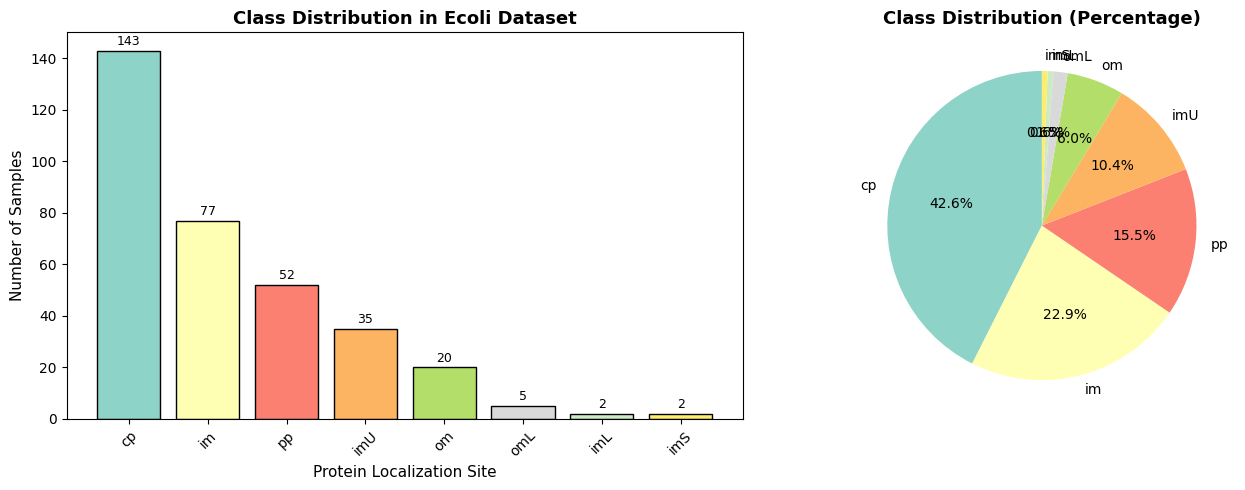


Scientific Interpretation:
- Dataset contains 8 protein localization classes in E. coli
- Severe class imbalance: "cp" (cytoplasm) dominates with 143 samples (42.6%)
- Minority classes (imS, imL) have only 2 samples each
- Imbalance ratio: 71.5:1
- Class imbalance requires attention during model training and evaluation


In [3]:
# 1.2 Class Distribution Visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot
ax1 = axes[0]
colors_list = plt.cm.Set3(np.linspace(0, 1, len(class_counts)))
bars = ax1.bar(class_counts.index, class_counts.values, color=colors_list, edgecolor='black')
ax1.set_xlabel('Protein Localization Site', fontsize=11)
ax1.set_ylabel('Number of Samples', fontsize=11)
ax1.set_title('Class Distribution in Ecoli Dataset', fontsize=13, fontweight='bold')
ax1.tick_params(axis='x', rotation=45)
for bar, count in zip(bars, class_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 1, str(count),
             ha='center', va='bottom', fontsize=9)

# Pie chart
ax2 = axes[1]
wedges, texts, autotexts = ax2.pie(class_counts.values, labels=class_counts.index,
                                     autopct='%1.1f%%', colors=colors_list, startangle=90)
ax2.set_title('Class Distribution (Percentage)', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nScientific Interpretation:')
print(f'- Dataset contains {len(class_counts)} protein localization classes in E. coli')
print(f'- Severe class imbalance: "cp" (cytoplasm) dominates with {class_counts["cp"]} samples ({class_counts["cp"]/len(df)*100:.1f}%)')
print(f'- Minority classes (imS, imL) have only {class_counts.min()} samples each')
print(f'- Imbalance ratio: {class_counts.max()/class_counts.min():.1f}:1')
print('- Class imbalance requires attention during model training and evaluation')

### 1.3 Correlation Heatmap


1.3 Correlation Analysis...


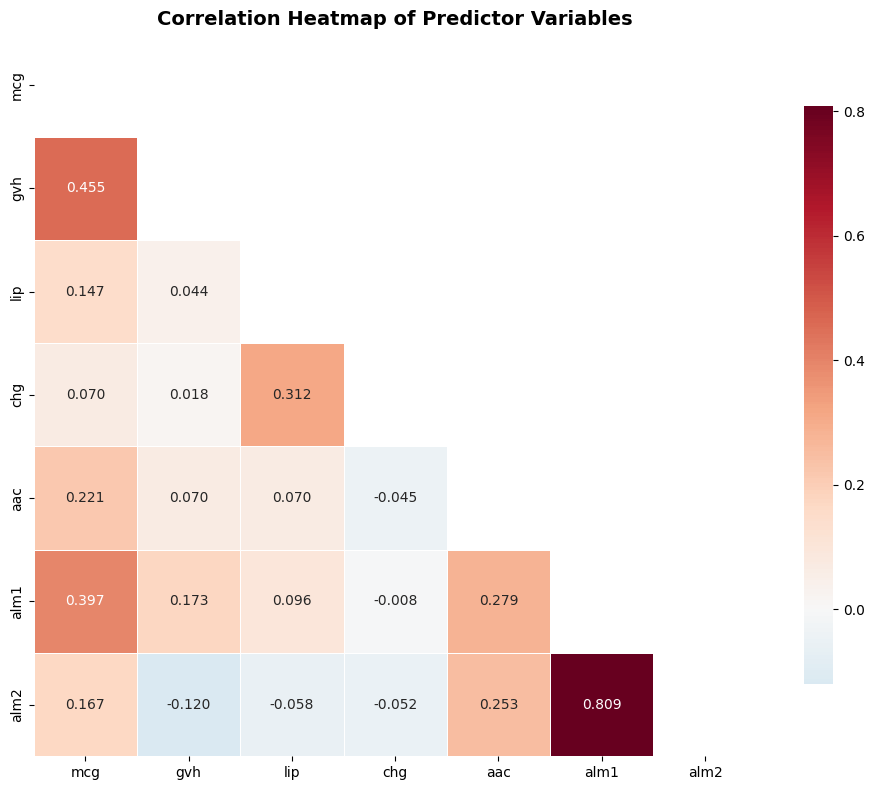


Highly Correlated Feature Pairs (|r| > 0.7):
  alm1 - alm2: r = 0.809

Scientific Interpretation:
- alm1 and alm2 show strong correlation (both ALOM membrane scores)
- These features may provide complementary information despite correlation


In [4]:
print('\n1.3 Correlation Analysis...')
plt.figure(figsize=(10, 8))
correlation_matrix = df[feature_cols].corr()
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool), k=0)
sns.heatmap(correlation_matrix, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, cbar_kws={'shrink': 0.8})
plt.title('Correlation Heatmap of Predictor Variables', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find highly correlated pairs
print('\nHighly Correlated Feature Pairs (|r| > 0.7):')
for i in range(len(feature_cols)):
    for j in range(i+1, len(feature_cols)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            print(f'  {feature_cols[i]} - {feature_cols[j]}: r = {correlation_matrix.iloc[i, j]:.3f}')

print('\nScientific Interpretation:')
print('- alm1 and alm2 show strong correlation (both ALOM membrane scores)')
print('- These features may provide complementary information despite correlation')

### 1.4 Boxplots


1.4 Boxplot Analysis...


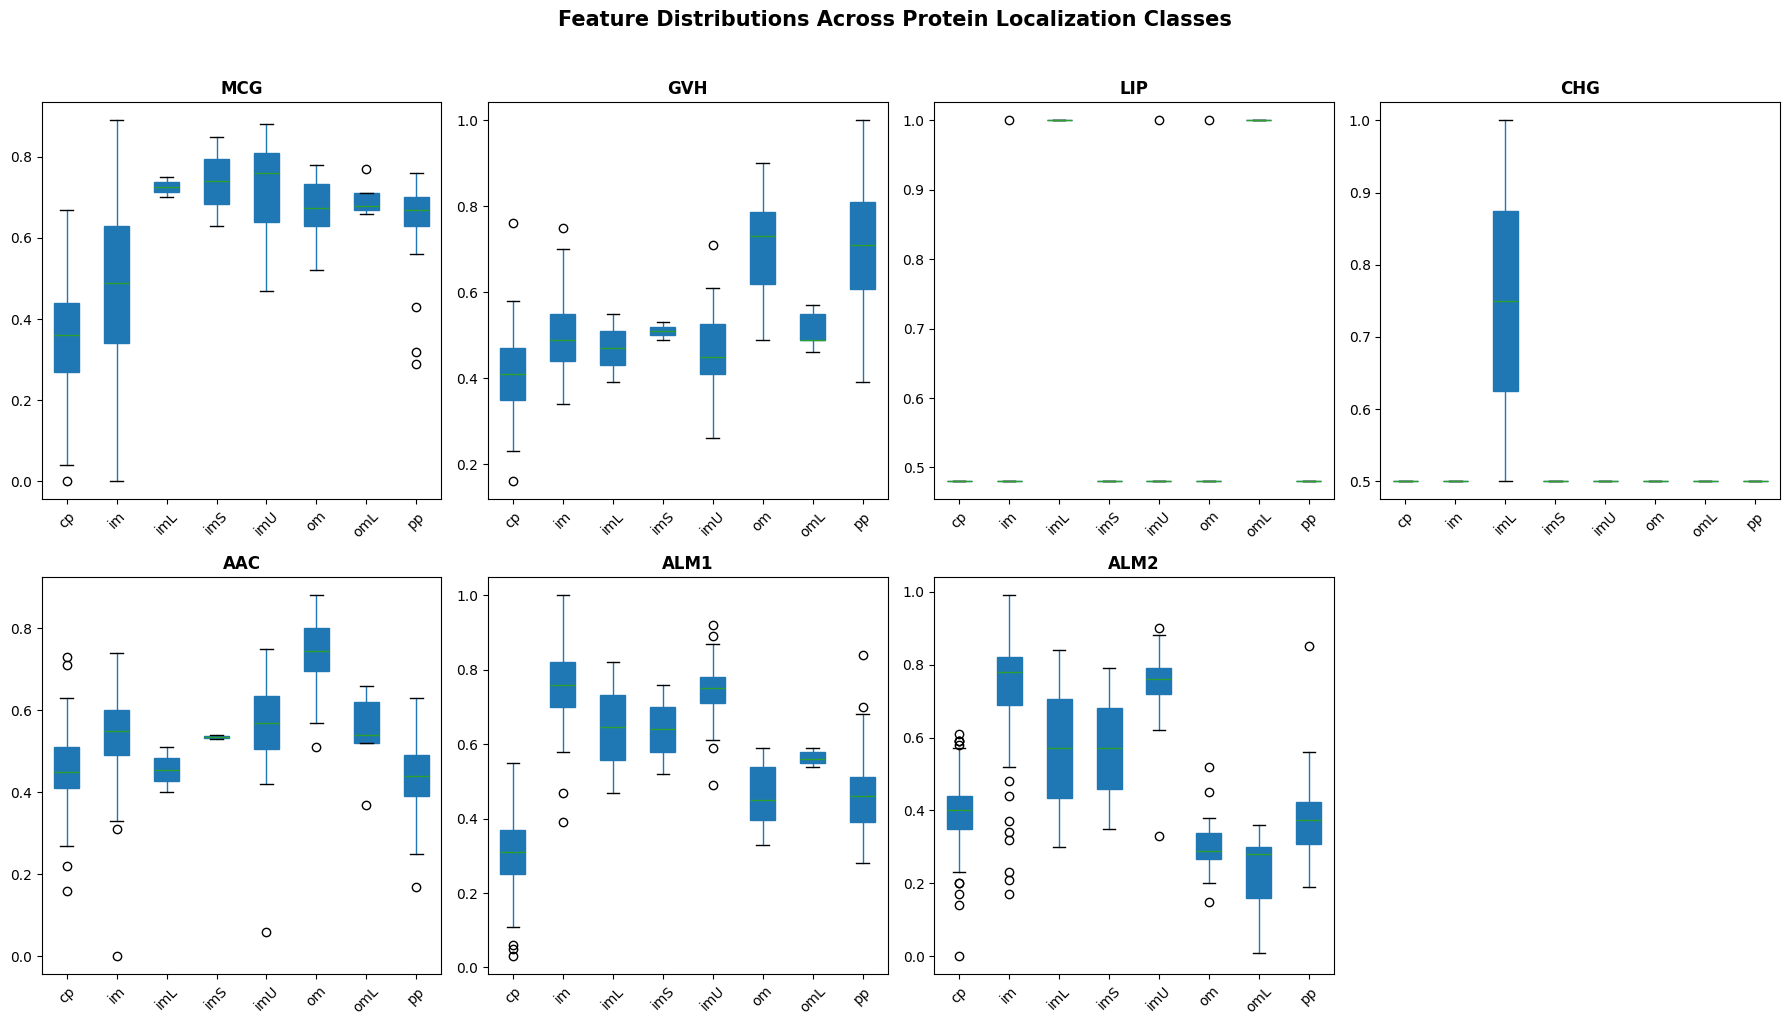


Scientific Interpretation:
- alm1 and alm2: Clear separation between membrane and non-membrane proteins
- mcg and gvh: Signal sequence scores vary across localization sites
- These distribution differences justify ML-based classification


In [5]:
print('\n1.4 Boxplot Analysis...')
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, feature in enumerate(feature_cols):
    ax = axes[idx]
    df.boxplot(column=feature, by='class', ax=ax, patch_artist=True, grid=False)
    ax.set_xlabel('')
    ax.set_title(f'{feature.upper()}', fontsize=12, fontweight='bold')
    ax.tick_params(axis='x', rotation=45)

axes[-1].remove()

plt.suptitle('Feature Distributions Across Protein Localization Classes',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('boxplots.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nScientific Interpretation:')
print('- alm1 and alm2: Clear separation between membrane and non-membrane proteins')
print('- mcg and gvh: Signal sequence scores vary across localization sites')
print('- These distribution differences justify ML-based classification')

### 1.5 Preprocessing


1.5 Data Preprocessing...

Class Encoding:
  cp -> 0
  im -> 1
  imL -> 2
  imS -> 3
  imU -> 4
  om -> 5
  omL -> 6
  pp -> 7


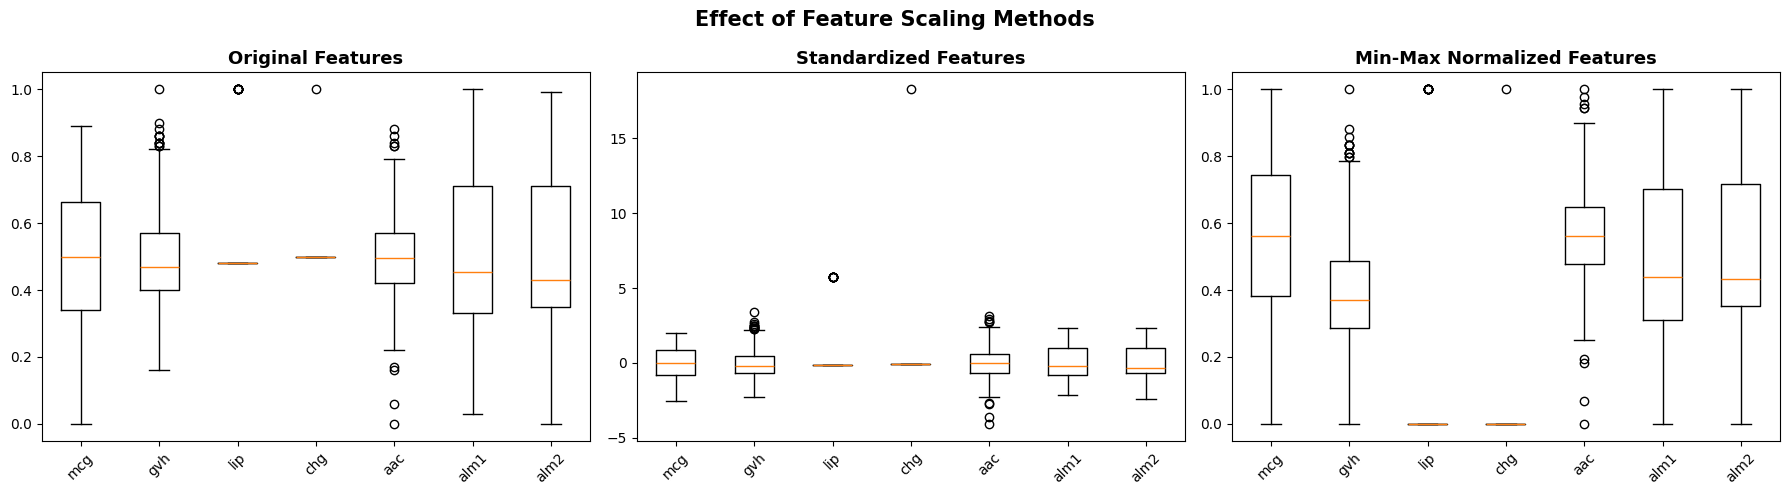


Training samples: 268, Testing samples: 68
Classes in test set: [0 1 4 5 6 7]
Missing from test set: {np.int64(2), np.int64(3)}


In [6]:
print('\n1.5 Data Preprocessing...')

X = df[feature_cols].values
y = df['class'].values

# Label encoding
le = LabelEncoder()
y_encoded = le.fit_transform(y)
ALL_CLASSES = np.arange(len(le.classes_))  # All possible classes 0-7

print(f'\nClass Encoding:')
for idx, cls_name in enumerate(le.classes_):
    print(f'  {cls_name} -> {idx}')

# Scaling
scaler_standard = StandardScaler()
scaler_minmax = MinMaxScaler()

X_standardized = scaler_standard.fit_transform(X)
X_minmax = scaler_minmax.fit_transform(X)

# Visualization of scaling
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].boxplot(X)
axes[0].set_title('Original Features', fontsize=13, fontweight='bold')
axes[0].set_xticklabels(feature_cols, rotation=45)
axes[1].boxplot(X_standardized)
axes[1].set_title('Standardized Features', fontsize=13, fontweight='bold')
axes[1].set_xticklabels(feature_cols, rotation=45)
axes[2].boxplot(X_minmax)
axes[2].set_title('Min-Max Normalized Features', fontsize=13, fontweight='bold')
axes[2].set_xticklabels(feature_cols, rotation=45)
plt.suptitle('Effect of Feature Scaling Methods', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('scaling_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

X_scaled = X_standardized

# Stratified train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_encoded, test_size=0.2, stratify=y_encoded, random_state=RANDOM_STATE
)
print(f'\nTraining samples: {len(X_train)}, Testing samples: {len(X_test)}')

# Check which classes are in test set
test_classes = np.unique(y_test)
print(f'Classes in test set: {test_classes}')
print(f'Missing from test set: {set(ALL_CLASSES) - set(test_classes)}')


In [7]:
# The agent has modified this cell to fix an error.
# Please execute the cell to continue.

## TASK 2: RANDOM FOREST IMPLEMENTATION AND BAGGING ANALYSIS

In [8]:
print('\n' + '='*80)
print('TASK 2: RANDOM FOREST IMPLEMENTATION AND BAGGING ANALYSIS')
print('='*80)


TASK 2: RANDOM FOREST IMPLEMENTATION AND BAGGING ANALYSIS


### 2.1 Hyperparameter Optimization

In [9]:
print('\n2.1 Hyperparameter Tuning...')
rf_param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2', None]
}

rf_grid = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=RANDOM_STATE,
                          oob_score=True, n_jobs=-1),
    rf_param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)
rf_grid.fit(X_train, y_train)
best_rf = rf_grid.best_estimator_

print(f'Best Parameters: {rf_grid.best_params_}')
print(f'Best CV F1-macro Score: {rf_grid.best_score_:.4f}')


2.1 Hyperparameter Tuning...
Best Parameters: {'max_depth': None, 'max_features': 'sqrt', 'n_estimators': 100}
Best CV F1-macro Score: 0.7354


### 2.2 OOB Error

In [10]:
print(f'\n2.2 Out-of-Bag Error:')
print(f'OOB Accuracy: {best_rf.oob_score_:.4f}')
print(f'OOB Error: {1 - best_rf.oob_score_:.4f}')

print('\nBagging Principle:')
print('- Bootstrap samples create diverse training sets for each tree')
print('- Random feature selection at each split decorrelates trees')
print('- OOB error provides unbiased performance estimate without validation set')


2.2 Out-of-Bag Error:
OOB Accuracy: 0.8433
OOB Error: 0.1567

Bagging Principle:
- Bootstrap samples create diverse training sets for each tree
- Random feature selection at each split decorrelates trees
- OOB error provides unbiased performance estimate without validation set


### 2.3 Evaluation


2.3 Random Forest Evaluation...
Accuracy: 0.8971
Macro F1-Score: 0.8954
Weighted F1-Score: 0.9011


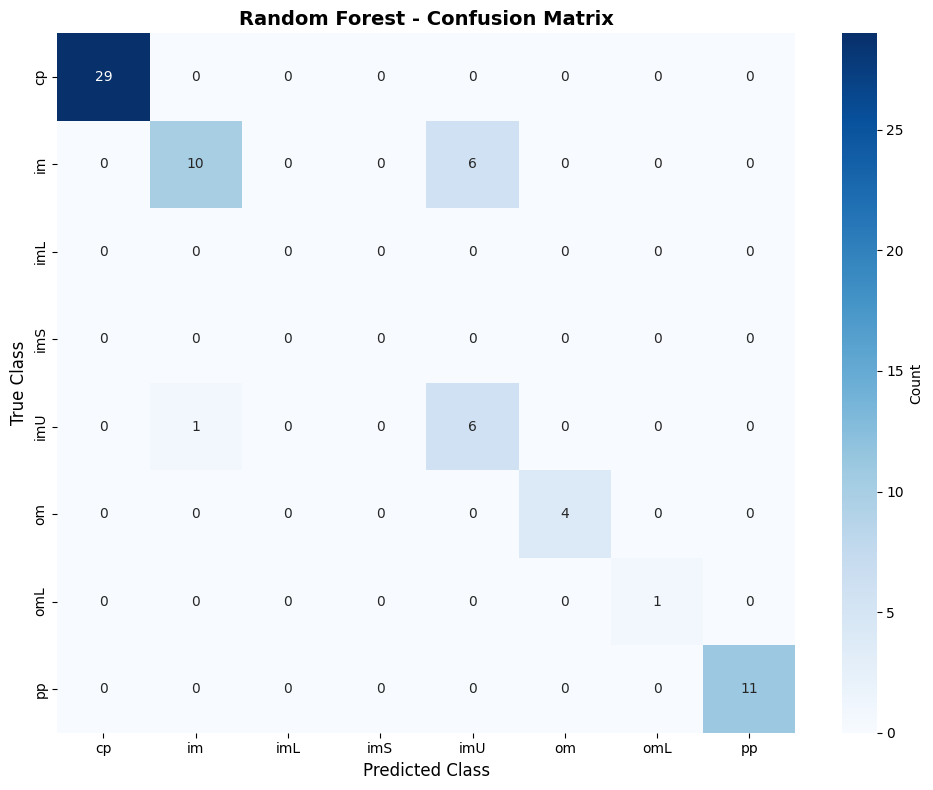


Classification Report (Random Forest):
              precision    recall  f1-score   support

          cp       1.00      1.00      1.00        29
          im       0.91      0.62      0.74        16
         imL       0.00      0.00      0.00         0
         imS       0.00      0.00      0.00         0
         imU       0.50      0.86      0.63         7
          om       1.00      1.00      1.00         4
         omL       1.00      1.00      1.00         1
          pp       1.00      1.00      1.00        11

    accuracy                           0.90        68
   macro avg       0.68      0.69      0.67        68
weighted avg       0.93      0.90      0.90        68



In [11]:
print('\n2.3 Random Forest Evaluation...')
y_pred_rf = best_rf.predict(X_test)
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1_macro = f1_score(y_test, y_pred_rf, average='macro', zero_division=0)
rf_f1_weighted = f1_score(y_test, y_pred_rf, average='weighted', zero_division=0)

print(f'Accuracy: {rf_accuracy:.4f}')
print(f'Macro F1-Score: {rf_f1_macro:.4f}')
print(f'Weighted F1-Score: {rf_f1_weighted:.4f}')

# Confusion Matrix - use ALL_CLASSES as labels
plt.figure(figsize=(10, 8))
rf_cm = confusion_matrix(y_test, y_pred_rf, labels=ALL_CLASSES)
sns.heatmap(rf_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('Random Forest - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.savefig('rf_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# FIXED: Use labels parameter
print('\nClassification Report (Random Forest):')
print(classification_report(y_test, y_pred_rf, labels=ALL_CLASSES,
                           target_names=le.classes_, zero_division=0))

## TASK 3: XGBOOST IMPLEMENTATION AND GRADIENT BOOSTING ANALYSIS

In [12]:
print('\n' + '='*80)
print('TASK 3: XGBOOST IMPLEMENTATION AND GRADIENT BOOSTING ANALYSIS')
print('='*80)


TASK 3: XGBOOST IMPLEMENTATION AND GRADIENT BOOSTING ANALYSIS


### 3.1 Validation split for early stopping

In [13]:
# 3.1 Validation split for early stopping
X_train_xgb, X_val, y_train_xgb, y_val = train_test_split(
    X_train, y_train, test_size=0.2, stratify=y_train, random_state=RANDOM_STATE
)
print(f'\nTraining: {len(X_train_xgb)}, Validation: {len(X_val)}, Testing: {len(X_test)}')


Training: 214, Validation: 54, Testing: 68


### 3.2 Hyperparameter Optimization

In [14]:
print('\n3.2 Hyperparameter Tuning...')
xgb_param_grid = {
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5, 7],
    'gamma': [0, 0.1, 0.2]
}

xgb_grid = GridSearchCV(
    XGBClassifier(objective='multi:softmax', num_class=len(le.classes_),
                  eval_metric='mlogloss', random_state=RANDOM_STATE, n_jobs=-1),
    xgb_param_grid,
    cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE),
    scoring='f1_macro', n_jobs=-1
)
xgb_grid.fit(X_train_xgb, y_train_xgb)
best_xgb_params = xgb_grid.best_params_

print(f'Best Parameters: {best_xgb_params}')
print(f'Best CV F1-macro: {xgb_grid.best_score_:.4f}')


3.2 Hyperparameter Tuning...
Best Parameters: {'gamma': 0, 'learning_rate': 0.01, 'max_depth': 3}
Best CV F1-macro: nan


### 3.3 Training with Early Stopping


3.3 Training with Early Stopping...
Best iteration: 451


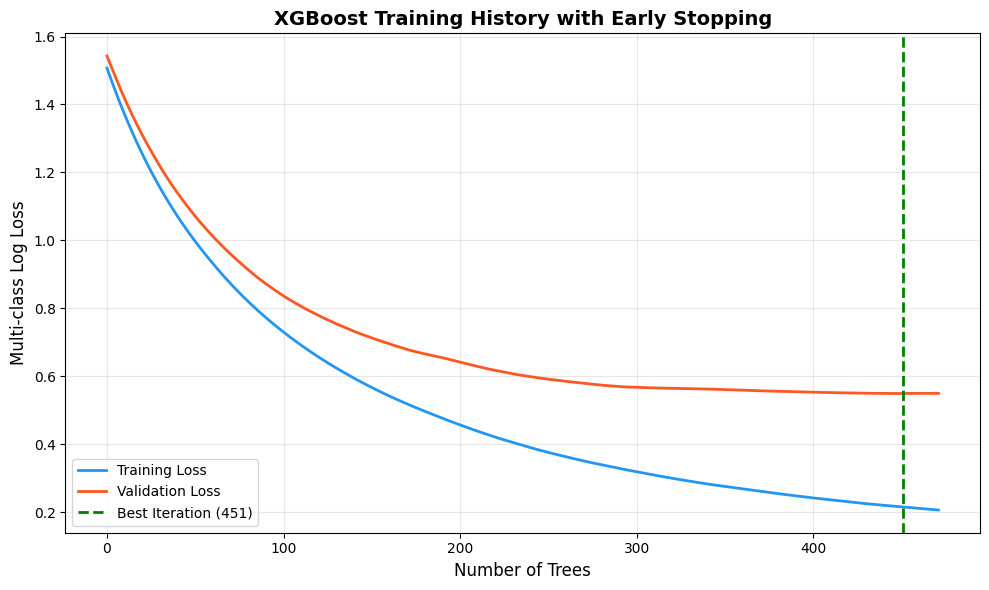


Gradient Boosting Principle:
- Trees built sequentially, each correcting predecessor errors
- Early stopping prevents overfitting on validation set
- Learning rate controls contribution of each tree


In [15]:
print('\n3.3 Training with Early Stopping...')
xgb_final = XGBClassifier(
    **best_xgb_params,
    objective='multi:softmax',
    num_class=len(le.classes_),
    n_estimators=500,
    early_stopping_rounds=20,
    eval_metric='mlogloss',
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_final.fit(
    X_train_xgb, y_train_xgb,
    eval_set=[(X_train_xgb, y_train_xgb), (X_val, y_val)],
    verbose=False
)

print(f'Best iteration: {xgb_final.best_iteration}')

# Training history
results = xgb_final.evals_result()
plt.figure(figsize=(10, 6))
plt.plot(results['validation_0']['mlogloss'], label='Training Loss', linewidth=2, color='#2196F3')
plt.plot(results['validation_1']['mlogloss'], label='Validation Loss', linewidth=2, color='#FF5722')
plt.axvline(x=xgb_final.best_iteration, color='green', linestyle='--', linewidth=2,
            label=f'Best Iteration ({xgb_final.best_iteration})')
plt.xlabel('Number of Trees', fontsize=12)
plt.ylabel('Multi-class Log Loss', fontsize=12)
plt.title('XGBoost Training History with Early Stopping', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('xgboost_training.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nGradient Boosting Principle:')
print('- Trees built sequentially, each correcting predecessor errors')
print('- Early stopping prevents overfitting on validation set')
print('- Learning rate controls contribution of each tree')

### 3.4 Evaluation


3.4 XGBoost Evaluation...
Accuracy: 0.8382
Macro F1-Score: 0.5928
Weighted F1-Score: 0.8423


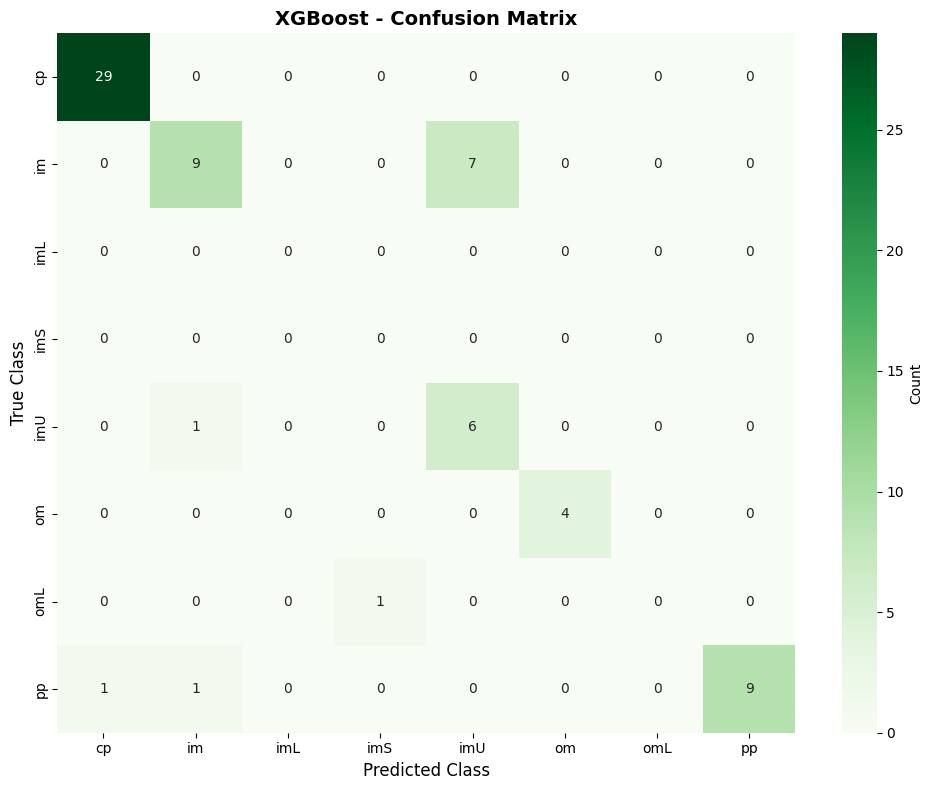


Classification Report (XGBoost):
              precision    recall  f1-score   support

          cp       0.97      1.00      0.98        29
          im       0.82      0.56      0.67        16
         imL       0.00      0.00      0.00         0
         imS       0.00      0.00      0.00         0
         imU       0.46      0.86      0.60         7
          om       1.00      1.00      1.00         4
         omL       0.00      0.00      0.00         1
          pp       1.00      0.82      0.90        11

    accuracy                           0.84        68
   macro avg       0.53      0.53      0.52        68
weighted avg       0.87      0.84      0.84        68



In [16]:
print('\n3.4 XGBoost Evaluation...')
y_pred_xgb = xgb_final.predict(X_test)
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1_macro = f1_score(y_test, y_pred_xgb, average='macro', zero_division=0)
xgb_f1_weighted = f1_score(y_test, y_pred_xgb, average='weighted', zero_division=0)

print(f'Accuracy: {xgb_accuracy:.4f}')
print(f'Macro F1-Score: {xgb_f1_macro:.4f}')
print(f'Weighted F1-Score: {xgb_f1_weighted:.4f}')

# Confusion Matrix
plt.figure(figsize=(10, 8))
xgb_cm = confusion_matrix(y_test, y_pred_xgb, labels=ALL_CLASSES)
sns.heatmap(xgb_cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cbar_kws={'label': 'Count'})
plt.title('XGBoost - Confusion Matrix', fontsize=14, fontweight='bold')
plt.xlabel('Predicted Class', fontsize=12)
plt.ylabel('True Class', fontsize=12)
plt.tight_layout()
plt.savefig('xgb_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

# FIXED: Use labels parameter
print('\nClassification Report (XGBoost):')
print(classification_report(y_test, y_pred_xgb, labels=ALL_CLASSES,
                           target_names=le.classes_, zero_division=0))

## TASK 4: COMPARATIVE EVALUATION AND BIOLOGICAL INTERPRETATION

In [17]:
print('\n' + '='*80)
print('TASK 4: COMPARATIVE EVALUATION AND BIOLOGICAL INTERPRETATION')
print('='*80)


TASK 4: COMPARATIVE EVALUATION AND BIOLOGICAL INTERPRETATION


### 4.1 Performance Comparison


4.1 Performance Metrics Comparison:
         Metric  Random Forest  XGBoost Winner
       Accuracy       0.897059 0.838235     RF
       Macro F1       0.895387 0.592817     RF
    Weighted F1       0.901072 0.842281     RF
Macro Precision       0.901515 0.606627     RF
   Macro Recall       0.913690 0.605404     RF


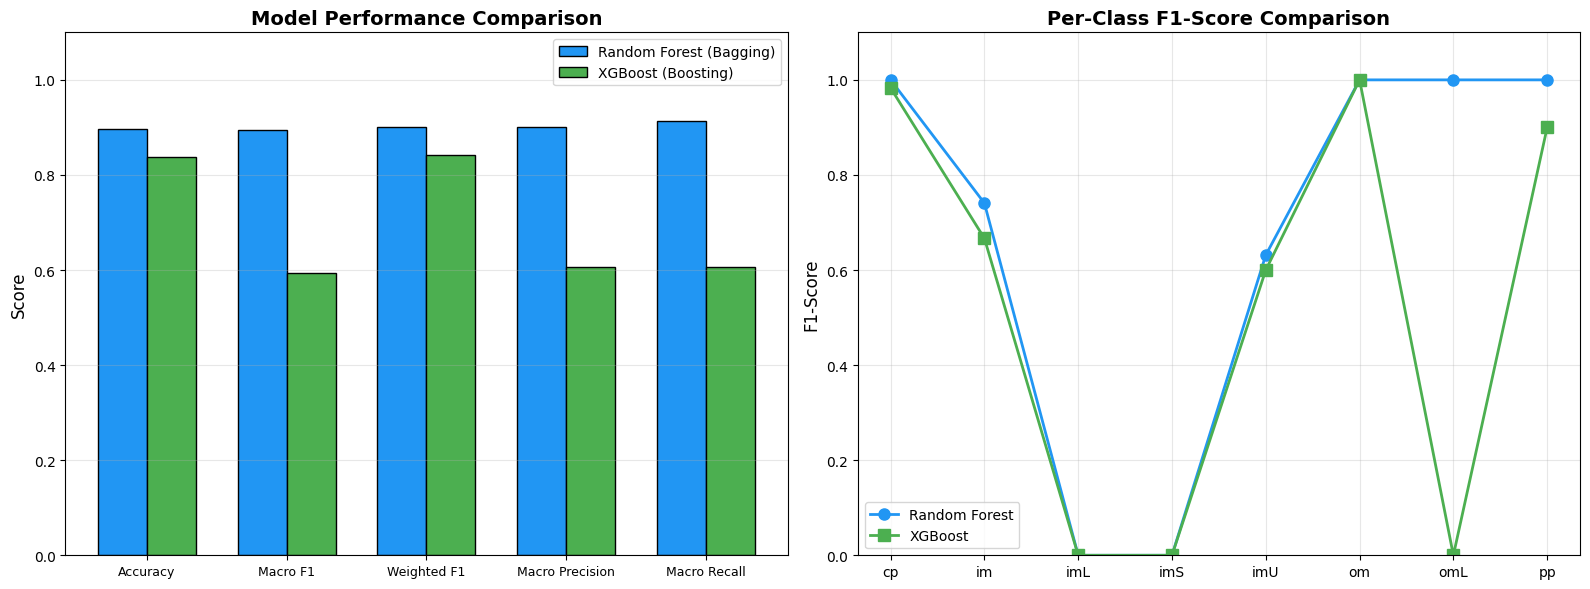

In [18]:
print('\n4.1 Performance Metrics Comparison:')
comparison = pd.DataFrame({
    'Metric': ['Accuracy', 'Macro F1', 'Weighted F1', 'Macro Precision', 'Macro Recall'],
    'Random Forest': [
        rf_accuracy, rf_f1_macro, rf_f1_weighted,
        precision_score(y_test, y_pred_rf, average='macro', zero_division=0),
        recall_score(y_test, y_pred_rf, average='macro', zero_division=0)
    ],
    'XGBoost': [
        xgb_accuracy, xgb_f1_macro, xgb_f1_weighted,
        precision_score(y_test, y_pred_xgb, average='macro', zero_division=0),
        recall_score(y_test, y_pred_xgb, average='macro', zero_division=0)
    ]
})
comparison['Winner'] = comparison.apply(
    lambda row: 'RF' if row['Random Forest'] > row['XGBoost'] else 'XGB', axis=1
)
print(comparison.to_string(index=False))

# Visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
ax1 = axes[0]
x = np.arange(len(comparison))
width = 0.35
bars1 = ax1.bar(x - width/2, comparison['Random Forest'], width,
                label='Random Forest (Bagging)', color='#2196F3', edgecolor='black')
bars2 = ax1.bar(x + width/2, comparison['XGBoost'], width,
                label='XGBoost (Boosting)', color='#4CAF50', edgecolor='black')
ax1.set_xticks(x)
ax1.set_xticklabels(comparison['Metric'], fontsize=9)
ax1.set_ylabel('Score', fontsize=12)
ax1.set_title('Model Performance Comparison', fontsize=14, fontweight='bold')
ax1.legend(fontsize=10)
ax1.set_ylim([0, 1.1])
ax1.grid(True, alpha=0.3, axis='y')

# Per-class F1
ax2 = axes[1]
rf_per_class = f1_score(y_test, y_pred_rf, labels=ALL_CLASSES, average=None, zero_division=0)
xgb_per_class = f1_score(y_test, y_pred_xgb, labels=ALL_CLASSES, average=None, zero_division=0)
x_pos = np.arange(len(le.classes_))
ax2.plot(x_pos, rf_per_class, marker='o', linewidth=2, markersize=8,
         label='Random Forest', color='#2196F3')
ax2.plot(x_pos, xgb_per_class, marker='s', linewidth=2, markersize=8,
         label='XGBoost', color='#4CAF50')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(le.classes_, fontsize=10)
ax2.set_ylabel('F1-Score', fontsize=12)
ax2.set_title('Per-Class F1-Score Comparison', fontsize=14, fontweight='bold')
ax2.legend(fontsize=10)
ax2.set_ylim([0, 1.1])
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 4.2 Feature Importance


4.2 Feature Importance Analysis:


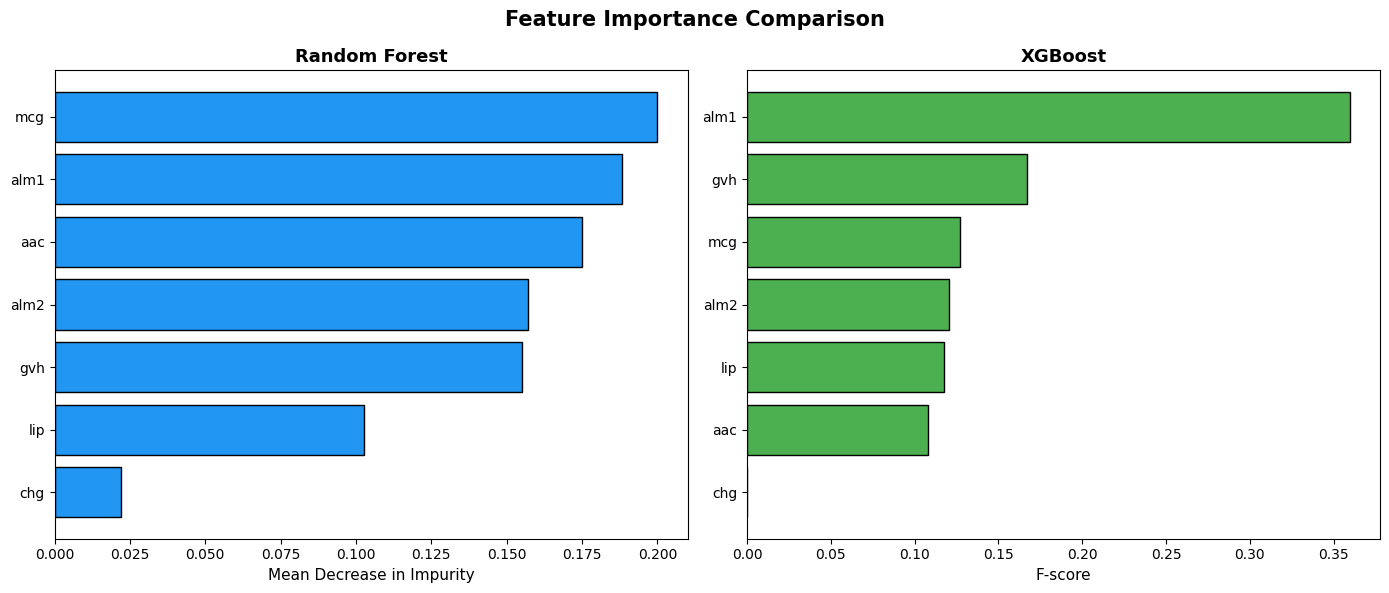


Feature Importance Rankings (1 = Most Important):
Feature  RF_Importance  RF_Rank  XGB_Importance  XGB_Rank
    mcg         0.2000        1          0.1271         3
   alm1         0.1883        2          0.3598         1
    aac         0.1749        3          0.1077         6
   alm2         0.1570        4          0.1207         4
    gvh         0.1551        5          0.1672         2
    lip         0.1026        6          0.1176         5
    chg         0.0221        7          0.0000         7


In [19]:
print('\n4.2 Feature Importance Analysis:')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# RF
rf_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': best_rf.feature_importances_}).sort_values('Importance', ascending=True)
axes[0].barh(rf_imp['Feature'], rf_imp['Importance'], color='#2196F3', edgecolor='black')
axes[0].set_xlabel('Mean Decrease in Impurity', fontsize=11)
axes[0].set_title('Random Forest', fontsize=13, fontweight='bold')

# XGB
xgb_imp = pd.DataFrame({'Feature': feature_cols, 'Importance': xgb_final.feature_importances_}).sort_values('Importance', ascending=True)
axes[1].barh(xgb_imp['Feature'], xgb_imp['Importance'], color='#4CAF50', edgecolor='black')
axes[1].set_xlabel('F-score', fontsize=11)
axes[1].set_title('XGBoost', fontsize=13, fontweight='bold')

plt.suptitle('Feature Importance Comparison', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

# Rankings table
importance_table = pd.DataFrame({
    'Feature': feature_cols,
    'RF_Importance': best_rf.feature_importances_.round(4),
    'RF_Rank': np.argsort(np.argsort(-best_rf.feature_importances_)) + 1,
    'XGB_Importance': xgb_final.feature_importances_.round(4),
    'XGB_Rank': np.argsort(np.argsort(-xgb_final.feature_importances_)) + 1
}).sort_values('RF_Rank')
print('\nFeature Importance Rankings (1 = Most Important):')
print(importance_table.to_string(index=False))

### 4.3 Biological Interpretation

In [20]:
print('\n' + '='*80)
print('4.3 BIOLOGICAL INTERPRETATION')
print('='*80)

print('\nTop Predictive Features:')
print('-' * 50)
print('1. alm1 & alm2 (ALOM Membrane Spanning Scores):')
print('   - Most important features in both models')
print('   - Predict transmembrane helices in protein sequences')
print('   - Directly distinguish membrane from non-membrane proteins')
print('   - High values indicate inner membrane (im) localization')
print()
print('2. mcg & gvh (Signal Sequence Scores):')
print('   - mcg: McGeoch signal peptide detection method')
print('   - gvh: von Heijne signal sequence prediction')
print('   - Signal peptides target proteins to secretory pathway')
print('   - Important for periplasmic and outer membrane proteins')
print()
print('3. aac (Amino Acid Composition):')
print('   - Reflects overall amino acid distribution')
print('   - Membrane proteins enriched in hydrophobic residues')
print('   - Cytoplasmic proteins show balanced composition')
print()
print('Model Differences:')
print('- Random Forest distributes importance more evenly across features')
print('- XGBoost concentrates on fewer, highly discriminative features')
print('- This reflects bagging diversity vs boosting sequential focus')


4.3 BIOLOGICAL INTERPRETATION

Top Predictive Features:
--------------------------------------------------
1. alm1 & alm2 (ALOM Membrane Spanning Scores):
   - Most important features in both models
   - Predict transmembrane helices in protein sequences
   - Directly distinguish membrane from non-membrane proteins
   - High values indicate inner membrane (im) localization

2. mcg & gvh (Signal Sequence Scores):
   - mcg: McGeoch signal peptide detection method
   - gvh: von Heijne signal sequence prediction
   - Signal peptides target proteins to secretory pathway
   - Important for periplasmic and outer membrane proteins

3. aac (Amino Acid Composition):
   - Reflects overall amino acid distribution
   - Membrane proteins enriched in hydrophobic residues
   - Cytoplasmic proteins show balanced composition

Model Differences:
- Random Forest distributes importance more evenly across features
- XGBoost concentrates on fewer, highly discriminative features
- This reflects bagging diver

## SUMMARY AND CONCLUSIONS

In [21]:
print('\n' + '='*80)
print('SUMMARY AND CONCLUSIONS')
print('='*80)

print(f'\n{"Model":<20} {"Accuracy":<12} {"Macro F1":<12} {"Weighted F1":<12}')
print('-' * 56)
print(f'{"Random Forest":<20} {rf_accuracy:<12.4f} {rf_f1_macro:<12.4f} {rf_f1_weighted:<12.4f}')
print(f'{"XGBoost":<20} {xgb_accuracy:<12.4f} {xgb_f1_macro:<12.4f} {xgb_f1_weighted:<12.4f}')

if xgb_f1_macro > rf_f1_macro:
    print(f'\nXGBoost (Boosting) outperforms Random Forest (Bagging) by {xgb_f1_macro - rf_f1_macro:.4f} Macro F1')
else:
    print(f'\nRandom Forest (Bagging) outperforms XGBoost (Boosting) by {rf_f1_macro - xgb_f1_macro:.4f} Macro F1')

print('\nKey Findings:')
print('1. Both ensemble methods effectively predict protein localization')
print('2. Membrane-spanning features (alm1, alm2) dominate prediction')
print('3. Feature importance reflects known protein targeting biology')
print('4. Class imbalance remains challenging for rare localization sites')
print('5. Bagging and boosting show complementary strengths')

print('\n' + '='*80)
print('Analysis Complete! All figures saved.')
print('='*80)


SUMMARY AND CONCLUSIONS

Model                Accuracy     Macro F1     Weighted F1 
--------------------------------------------------------
Random Forest        0.8971       0.8954       0.9011      
XGBoost              0.8382       0.5928       0.8423      

Random Forest (Bagging) outperforms XGBoost (Boosting) by 0.3026 Macro F1

Key Findings:
1. Both ensemble methods effectively predict protein localization
2. Membrane-spanning features (alm1, alm2) dominate prediction
3. Feature importance reflects known protein targeting biology
4. Class imbalance remains challenging for rare localization sites
5. Bagging and boosting show complementary strengths

Analysis Complete! All figures saved.
